In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Se importa el archivo como .CSV y se lo guarda en un set de datos.

In [109]:
df = pd.read_csv("Trabajo Integrador - Estadistica - Datos Brutos.csv", skiprows=2)
df = df.drop(columns=["Unnamed: 2"])
df.head()

,Horas de consumo de redes sociales por día,Rendimieno académico
0,5,7
1,1,8
2,3,8
3,3,8
4,6,7


# Se ajusta el nombre de las variables para hacerlas más accesibles

In [110]:
df = df.rename(columns={"Horas de  consumo de redes sociales por día": "x", "Rendimieno académico": "y"})
df.head()

,x,y
0,5,7
1,1,8
2,3,8
3,3,8
4,6,7


# Se guarda únicamente la variable xi (horas de consumo) y se calculan las frecuencias absolutas, frecuencias acumuladas, frecuencias relativas, frecuencias relativas acumuladas, y frecuencias porcentuales.

In [111]:
df_xi = df.copy()
df_xi = df_xi.drop(columns="y")
tabla_frecuencias = df_xi.groupby("x").size().reset_index(name="fi")
tabla_frecuencias = tabla_frecuencias.rename(columns={"x": "xi"})

n_datos = tabla_frecuencias["fi"].sum()

tabla_frecuencias["Fi"] = tabla_frecuencias["fi"].cumsum()
tabla_frecuencias["pi"] = tabla_frecuencias["fi"] / n_datos
tabla_frecuencias["Pi"] = tabla_frecuencias["pi"].cumsum()
tabla_frecuencias["pi%"] = tabla_frecuencias["pi"] * 100
tabla_frecuencias["Pi%"] = tabla_frecuencias["Pi"] * 100
tabla_frecuencias

,xi,fi,Fi,pi,Pi,pi%,Pi%
0,0,11,11,0.022449,0.022449,2.244898,2.244898
1,1,18,29,0.036735,0.059184,3.673469,5.918367
2,2,52,81,0.106122,0.165306,10.612245,16.530612
3,3,102,183,0.208163,0.373469,20.816327,37.346939
4,4,92,275,0.187755,0.561224,18.775510,56.122449
5,5,81,356,0.165306,0.726531,16.530612,72.653061
6,6,44,400,0.089796,0.816327,8.979592,81.632653
7,7,45,445,0.091837,0.908163,9.183673,90.816327
8,8,17,462,0.034694,0.942857,3.469388,94.285714
9,9,14,476,0.028571,0.971429,2.857143,97.142857


In [112]:
n_datos

np.int64(490)

In [113]:
print("Variable X: Horas de consumo de redes sociales por día")
print("Variable Y: Rendimiento académico")

Variable X: Horas de consumo de redes sociales por día
Variable Y: Rendimiento académico


# Se crean columnas para guardar los datos necesarios para aplicar la Regresión Lineal

In [114]:
df["x*y"] = df["x"]*df["y"]
df["x^2"] = df["x"] ** 2
df["y^2"] = df["y"] ** 2
df.head()

,x,y,x*y,x^2,y^2
0,5,7,35,25,49
1,1,8,8,1,64
2,3,8,24,9,64
3,3,8,24,9,64
4,6,7,42,36,49


In [115]:
n = 489
sum_x = df["x"].sum()
sum_y = df["y"].sum()
sum_xy = df["x*y"].sum()
sum_x2 = df["x^2"].sum()
sum_y2 = df["y^2"].sum()
print("Sumatoria de X:",sum_x)
print("Sumatoria de Y:",sum_y)
print("Sumatoria de X*Y:",sum_xy)
print("Sumatoria de X^2:",sum_x2)
print("Sumatoria de Y^2:",sum_y2)

Sumatoria de X: 2192
Sumatoria de Y: 3468
Sumatoria de X*Y: 14975
Sumatoria de X^2: 12268
Sumatoria de Y^2: 24892


In [116]:
b = ((n * sum_xy) - (sum_x * sum_y)) / ((n * sum_x2) - (sum_x ** 2))
a = ((sum_y * sum_x2) - (sum_xy * sum_x)) / ((n * sum_x2) - (sum_x ** 2))
print("Pendiente b:",f"{b:.2f}")
print("Ordenada al origen a:",f"{a:.2f}")
print("Ecuación de recta de regresión y = -0.23x + 8.14")

Pendiente b: -0.23
Ordenada al origen a: 8.14
Ecuación de recta de regresión y = -0.23x + 8.14


## Ecuación de regresión: y = -0.23x + 8.14
- Ordenada al origen (a = 8.14): Un estudiante que no consume redes sociales en absoluto tendría un rendimiento académico estimado de 8.14 puntos.
- Pendiente (b = -0.23): Por cada hora adicional de redes sociales por día, el rendimiento académico cae en promedio 0.23 puntos. Un estudiante que pasa 5 horas diarias en redes tendría un rendimiento esperado de unos 6.99 puntos, contra los 8.13 de alguien que no las usa, una diferencia de más de un punto.

In [117]:
r = ((n * sum_xy) - (sum_x * sum_y)) / np.sqrt(((n * sum_x2) - (sum_x ** 2)) * ((n * sum_y2) - (sum_y ** 2)))
r2 = r**2
print("Coeficiente de correlación r:",f"{r:.2f}")
print("R^2:",f"{r2:.2f}")

Coeficiente de correlación r: -0.67
R^2: 0.45


## Coeficiente de correlación: r = -0.67
- El signo negativo confirma que la relación es inversa: más redes, menos rendimiento. La magnitud (-0.67) indica una correlación moderada. No es débil ni fuerte: existe una tendencia clara, pero hay mucha variabilidad individual, hay estudiantes que usan muchas horas de redes y tienen un buen rendimiento, y viceversa.

## Coeficiente de determinación: R² = 0.45
- El consumo de redes sociales explica el 45% de la variación en el rendimiento académico.

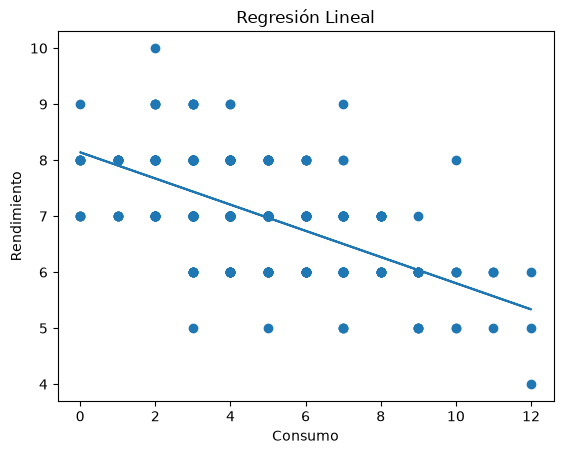

In [118]:
x = np.array(df["x"])
y = a + b*x

plt.scatter(df["x"], df["y"])
plt.plot(x, y)

plt.title("Regresión Lineal")
plt.xlabel("Consumo")
plt.ylabel("Rendimiento")

plt.show()


# El gráfico muestra una tendencia descendente real pero con una notoria variabilidad individual. La recta captura la tendencia general, pero predecir el rendimiento de un estudiante puntual a partir de su consumo de redes sería impreciso.